# Single Category (Gaming)

In [1]:
import pandas as pd
import numpy as np
import requests
import cv2
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor

# -------- Load data --------
df = pd.read_parquet("yt_cleaned.parquet")

df["video_view_count"] = pd.to_numeric(df["video_view_count"], errors="coerce")
df["channel_subscriber_count"] = pd.to_numeric(df["channel_subscriber_count"], errors="coerce")

df = df.dropna(subset=[
    "video_view_count",
    "channel_subscriber_count",
    "video_default_thumbnail"
])

# -------- Filter category --------
gaming_df = df[df["video_category_id"] == "Gaming"]

# -------- Sample --------
sample_df = gaming_df.sample(1000, random_state=42)

# -------- Thumbnail analysis --------
def analyze_thumbnail(row):
    try:
        url = row["video_default_thumbnail"]

        response = requests.get(url, timeout=5)
        if response.status_code != 200:
            return None

        img = Image.open(BytesIO(response.content)).convert("RGB")

        # resize (speed)
        img = img.resize((64, 64))

        img_np = np.array(img)

        # remove bad images
        if np.std(img_np) < 10:
            return None

        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        saturation = hsv[:, :, 1]
        brightness = hsv[:, :, 2]

        avg_sat = np.mean(saturation)
        bright_ratio = np.sum(brightness > 200) / brightness.size

        virality = row["video_view_count"] / row["channel_subscriber_count"]

        return avg_sat, bright_ratio, virality

    except:
        return None


# -------- Parallel processing --------
results = []

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = [executor.submit(analyze_thumbnail, row) for _, row in sample_df.iterrows()]

    for f in futures:
        res = f.result()
        if res is not None:
            results.append(res)

# -------- Create final dataframe --------
result_df = pd.DataFrame(results, columns=[
    "avg_saturation",
    "bright_ratio",
    "virality"
])

# -------- Clean data --------
result_df = result_df[result_df["virality"] > 0]
result_df = result_df[result_df["virality"] < 50]
result_df = result_df[result_df["avg_saturation"] > 5]
result_df = result_df[result_df["bright_ratio"] < 0.8]

result_df = result_df.drop_duplicates(subset=[
    "avg_saturation", "bright_ratio"
])

print(result_df.head())

   avg_saturation  bright_ratio  virality
0      117.743896      0.347900  0.749549
1      141.943604      0.123291  0.096173
2       49.269287      0.486084  0.011469
3      110.160400      0.438965  0.082066
4      143.174072      0.303223  1.064476


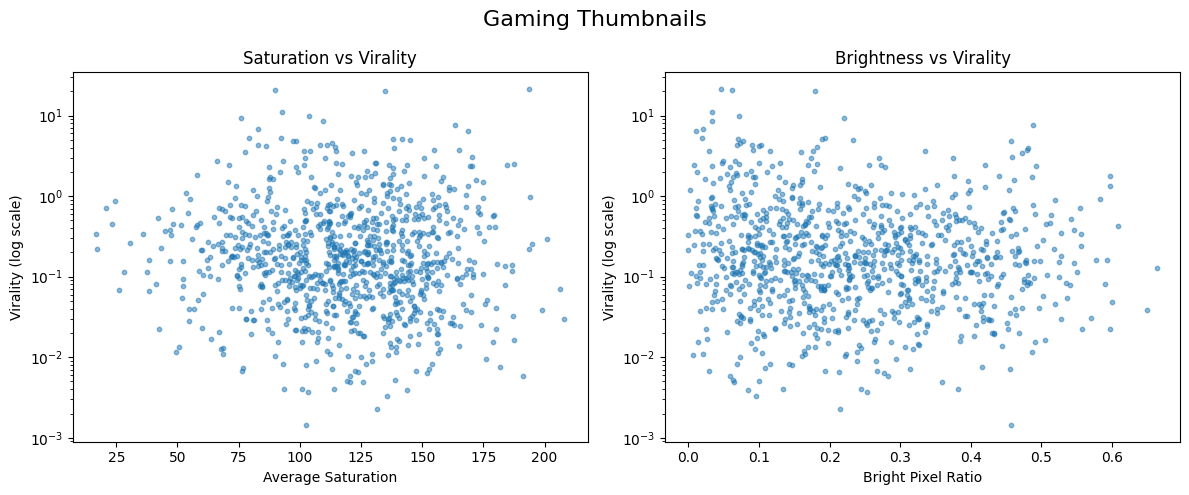

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- Plot 1: Saturation --------
axes[0].scatter(result_df["avg_saturation"], result_df["virality"], s=10, alpha=0.5)
axes[0].set_yscale("log")
axes[0].set_xlabel("Average Saturation")
axes[0].set_ylabel("Virality (log scale)")
axes[0].set_title("Saturation vs Virality")

# -------- Plot 2: Brightness --------
axes[1].scatter(result_df["bright_ratio"], result_df["virality"], s=10, alpha=0.5)
axes[1].set_yscale("log")
axes[1].set_xlabel("Bright Pixel Ratio")
axes[1].set_ylabel("Virality (log scale)")
axes[1].set_title("Brightness vs Virality")

# -------- Main title --------
fig.suptitle("Gaming Thumbnails", fontsize=16)

plt.tight_layout()
plt.show()

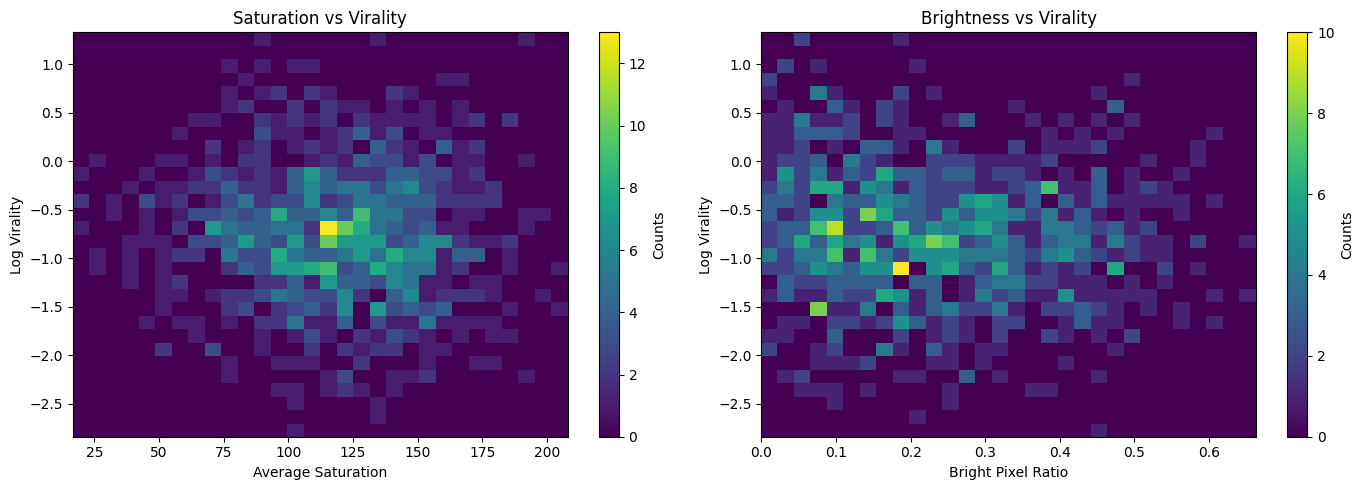

In [4]:
import numpy as np
import matplotlib.pyplot as plt

log_virality = np.log10(result_df["virality"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heatmap1, xedges1, yedges1 = np.histogram2d(
    result_df["avg_saturation"],
    log_virality,
    bins=30
)

im1 = axes[0].imshow(
    heatmap1.T,
    origin='lower',
    aspect='auto',
    extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]]
)

axes[0].set_xlabel("Average Saturation")
axes[0].set_ylabel("Log Virality")
axes[0].set_title("Saturation vs Virality")

fig.colorbar(im1, ax=axes[0], label="Counts")

# -------- Heatmap 2: Brightness --------
heatmap2, xedges2, yedges2 = np.histogram2d(
    result_df["bright_ratio"],
    log_virality,
    bins=30
)

im2 = axes[1].imshow(
    heatmap2.T,
    origin='lower',
    aspect='auto',
    extent=[xedges2[0], xedges2[-1], yedges2[0], yedges2[-1]]
)

axes[1].set_xlabel("Bright Pixel Ratio")
axes[1].set_ylabel("Log Virality")
axes[1].set_title("Brightness vs Virality")

fig.colorbar(im2, ax=axes[1], label="Counts")

# -------- Final layout --------
plt.tight_layout()
plt.show()

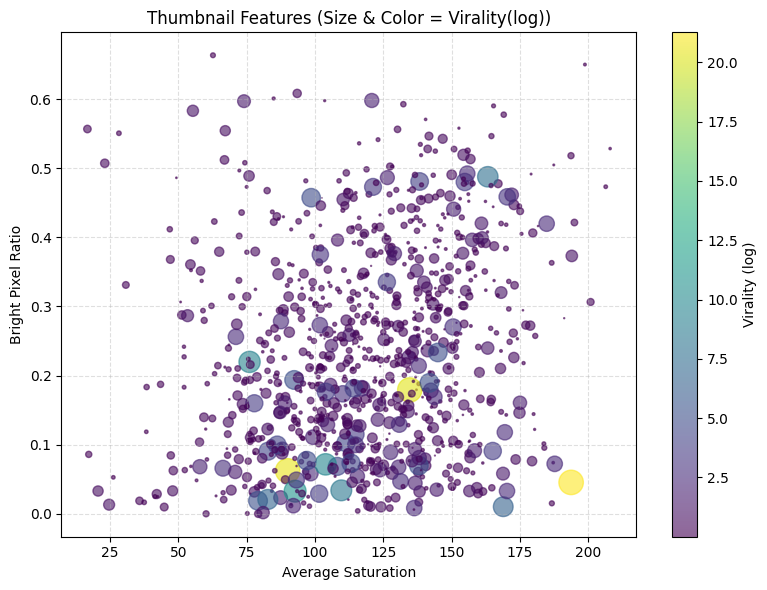

In [21]:
sizes = np.log1p(result_df["virality"]) * 100

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    result_df["avg_saturation"],
    result_df["bright_ratio"],
    s=sizes,
    c=result_df["virality"],
    alpha=0.6
)

plt.xlabel("Average Saturation")
plt.ylabel("Bright Pixel Ratio")
plt.title("Thumbnail Features (Size & Color = Virality(log))")

plt.colorbar(sc, label="Virality (log)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# All categories included

In [5]:
categories = df["video_category_id"].unique()
print(categories)

<ArrowStringArray>
[                'Music',                'Sports',                'Gaming',
        'People & Blogs',         'Entertainment',       'News & Politics',
                'Comedy',      'Film & Animation',         'Howto & Style',
             'Education',       'Travel & Events',        'Pets & Animals',
  'Science & Technology',                     nan,      'Autos & Vehicles',
 'Nonprofits & Activism']
Length: 16, dtype: str


In [6]:
import pandas as pd
import numpy as np
import requests
import cv2
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt

In [7]:
df = pd.read_parquet("yt_cleaned.parquet")

# convert numeric columns
df["video_view_count"] = pd.to_numeric(df["video_view_count"], errors="coerce")
df["channel_subscriber_count"] = pd.to_numeric(df["channel_subscriber_count"], errors="coerce")

# drop invalid rows
df = df.dropna(subset=[
    "video_view_count",
    "channel_subscriber_count",
    "video_default_thumbnail",
    "video_category_id"
])

In [8]:
def analyze_thumbnail(row):
    try:
        url = row["video_default_thumbnail"]

        response = requests.get(url, timeout=5)
        if response.status_code != 200:
            return None

        img = Image.open(BytesIO(response.content)).convert("RGB")

        # resize for speed
        img = img.resize((64, 64))

        img_np = np.array(img)

        # remove bad images
        if np.std(img_np) < 10:
            return None

        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        saturation = hsv[:, :, 1]
        brightness = hsv[:, :, 2]

        avg_sat = np.mean(saturation)
        bright_ratio = np.sum(brightness > 200) / brightness.size

        virality = row["video_view_count"] / row["channel_subscriber_count"]

        return avg_sat, bright_ratio, virality

    except:
        return None


In [9]:
def process_category(df, category, sample_size=1000):
    print(f"Processing {category}...")

    cat_df = df[df["video_category_id"] == category]

    if len(cat_df) == 0:
        return None

    sample_size = min(sample_size, len(cat_df))
    sample_df = cat_df.sample(sample_size, random_state=42)

    rows = sample_df.to_dict("records")

    results = []

    with ThreadPoolExecutor(max_workers=20) as executor:
        futures = [executor.submit(analyze_thumbnail, row) for row in rows]

        for f in futures:
            res = f.result()
            if res is not None:
                results.append(res)

    if len(results) == 0:
        return None

    result_df = pd.DataFrame(results, columns=[
        "avg_saturation",
        "bright_ratio",
        "virality"
    ])

    # clean data
    result_df = result_df[result_df["virality"] > 0]
    result_df = result_df[result_df["virality"] < 50]
    result_df = result_df[result_df["avg_saturation"] > 5]
    result_df = result_df[result_df["bright_ratio"] < 0.8]

    result_df = result_df.drop_duplicates(subset=[
        "avg_saturation", "bright_ratio"
    ])

    result_df["category"] = category

    return result_df


In [10]:
categories = df["video_category_id"].dropna().unique()

all_results = []

for cat in categories:
    res = process_category(df, cat)

    if res is not None and len(res) > 0:
        all_results.append(res)

final_df = pd.concat(all_results, ignore_index=True)

Processing Music...
Processing Sports...
Processing Gaming...
Processing People & Blogs...
Processing Entertainment...
Processing News & Politics...
Processing Comedy...
Processing Film & Animation...
Processing Howto & Style...
Processing Education...
Processing Travel & Events...
Processing Pets & Animals...
Processing Science & Technology...
Processing Autos & Vehicles...
Processing Nonprofits & Activism...

Final Data:
   avg_saturation  bright_ratio   virality category
0      120.248047      0.172363   0.037486    Music
1      174.305420      0.041016  14.156707    Music
2       99.360840      0.041504  18.298839    Music
3       23.237793      0.000000   0.414133    Music
4       92.867676      0.002930   0.684191    Music


In [11]:
summary = final_df.groupby("category").agg({
    "avg_saturation": "mean",
    "bright_ratio": "mean",
    "virality": "mean"
})

print("\nSummary:")
print(summary)


Summary:
                       avg_saturation  bright_ratio  virality
category                                                     
Autos & Vehicles            83.599195      0.150896  0.885061
Comedy                      90.747639      0.150844  2.059520
Education                   94.900150      0.156999  1.994306
Entertainment               98.290834      0.166331  1.742640
Film & Animation           105.222255      0.159387  2.761389
Gaming                     118.471955      0.234485  0.557916
Howto & Style               89.911529      0.196523  4.485393
Music                       99.773660      0.114379  2.298485
News & Politics             89.517594      0.123106  1.277021
Nonprofits & Activism       43.533813      0.203613  7.646728
People & Blogs              94.635193      0.164019  3.405530
Pets & Animals              73.819623      0.156710  1.958384
Science & Technology        91.090801      0.187874  1.072206
Sports                     100.708946      0.149700  1.64119

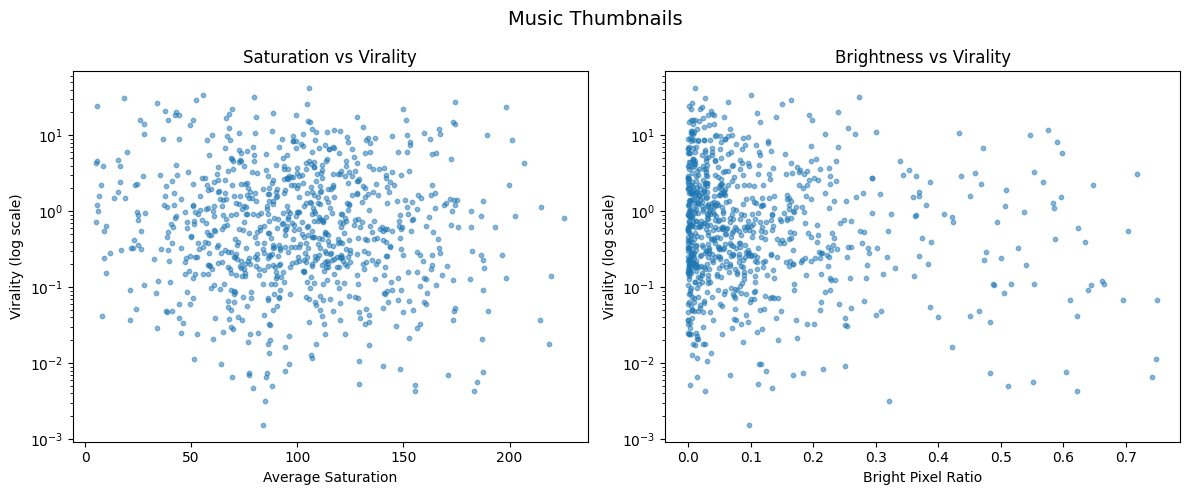

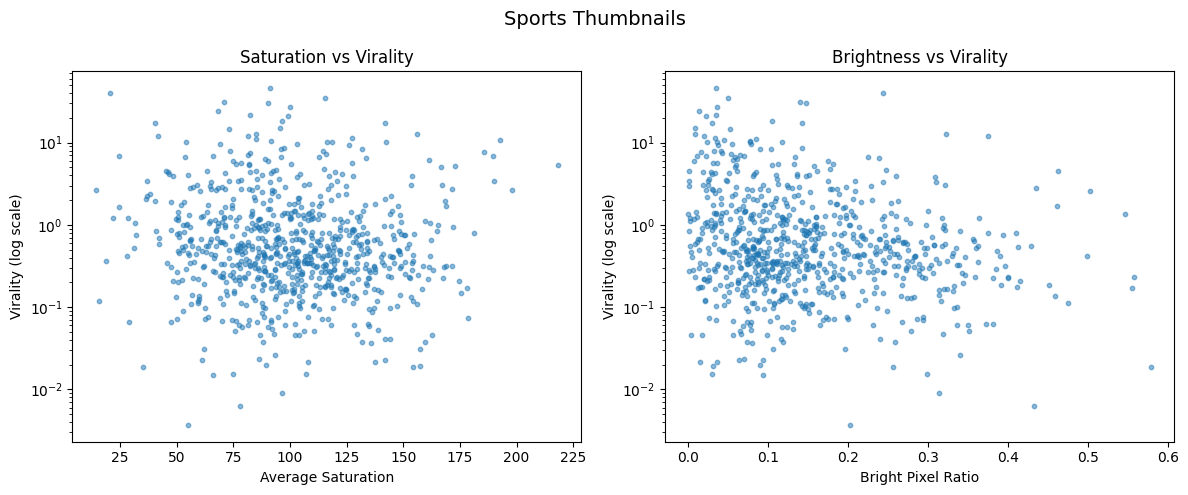

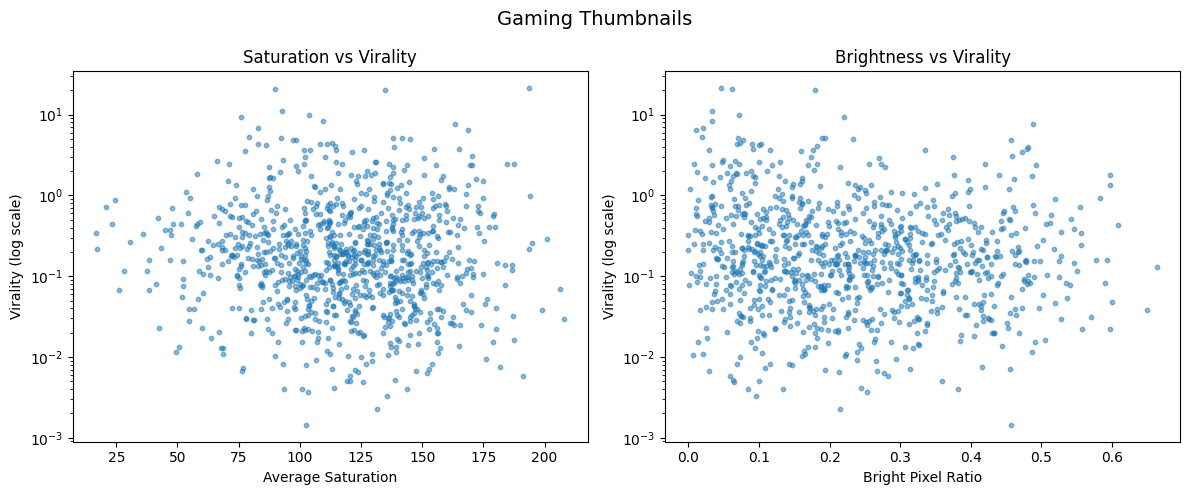

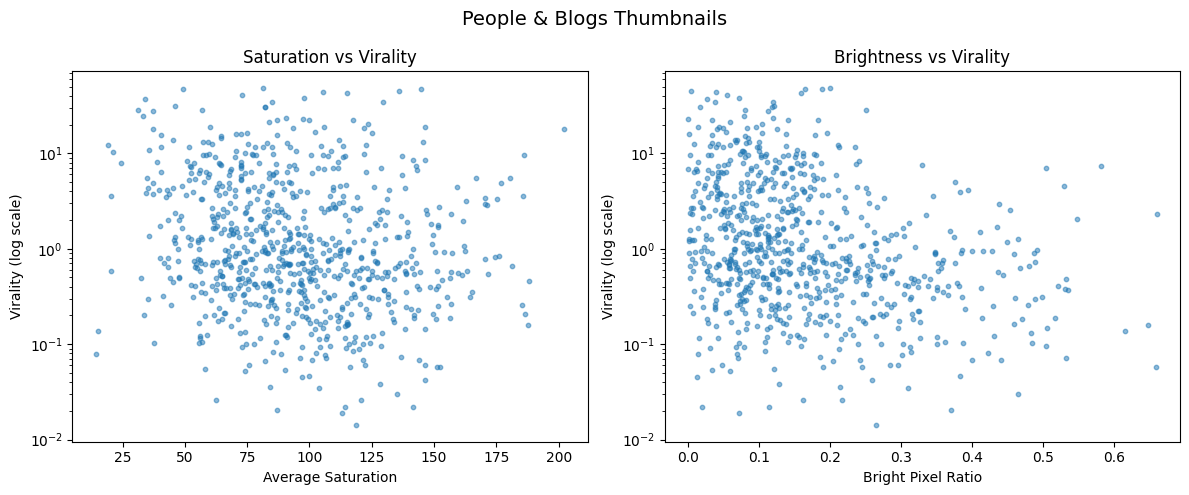

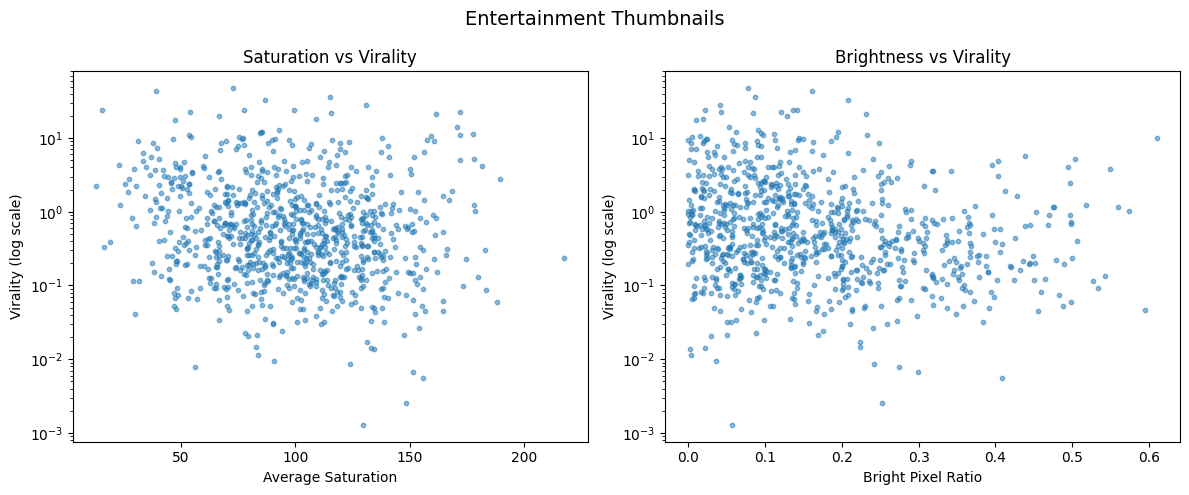

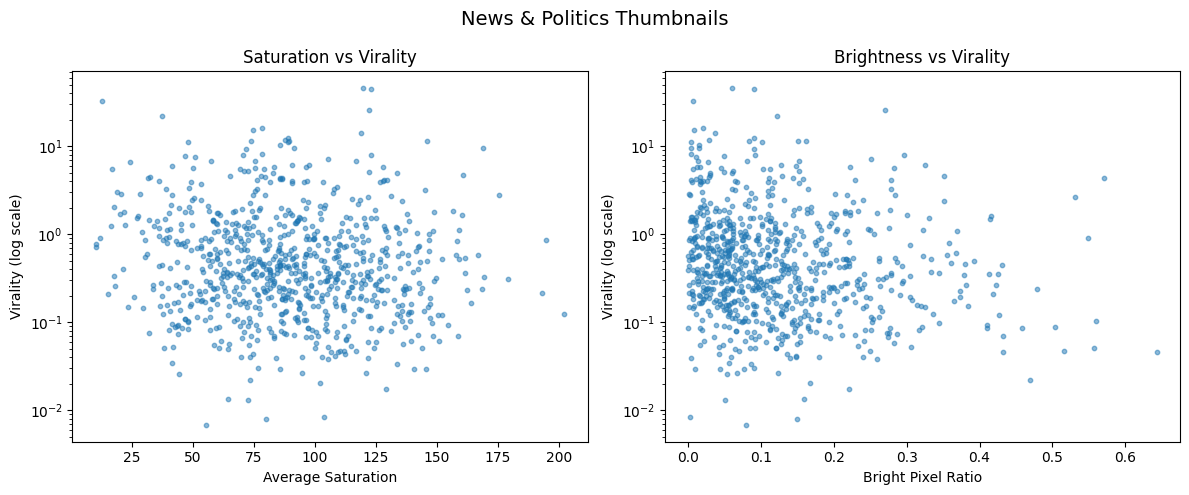

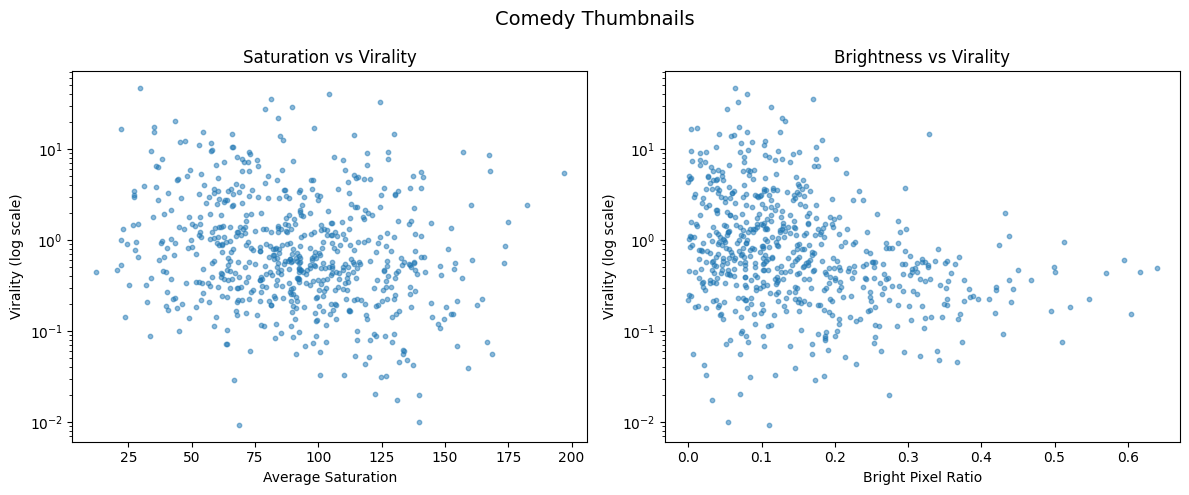

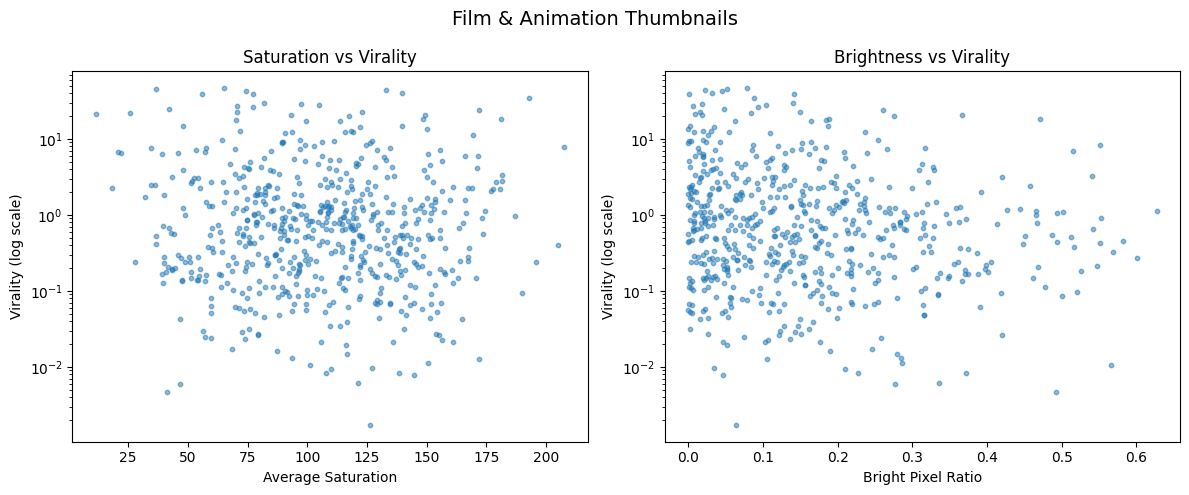

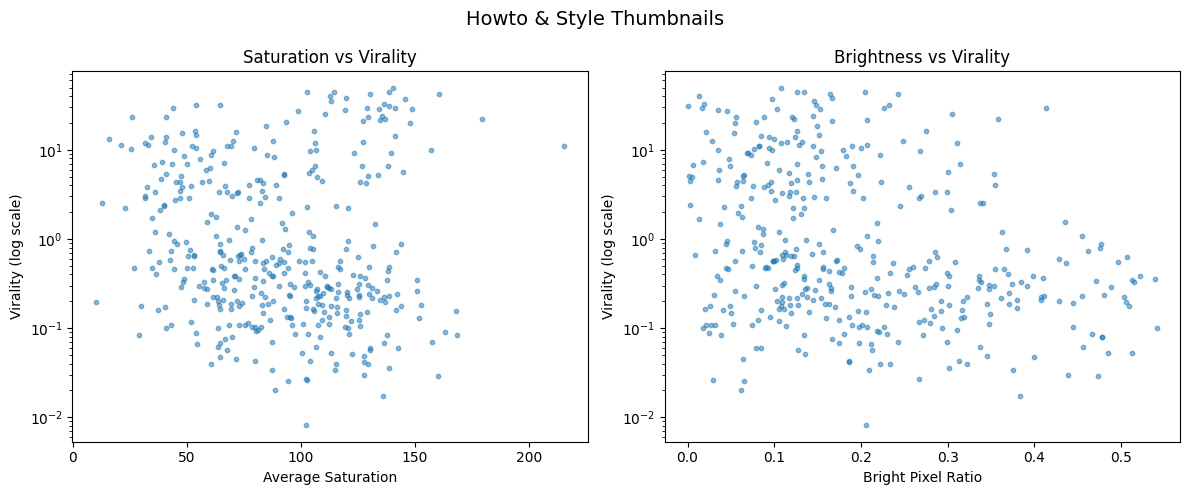

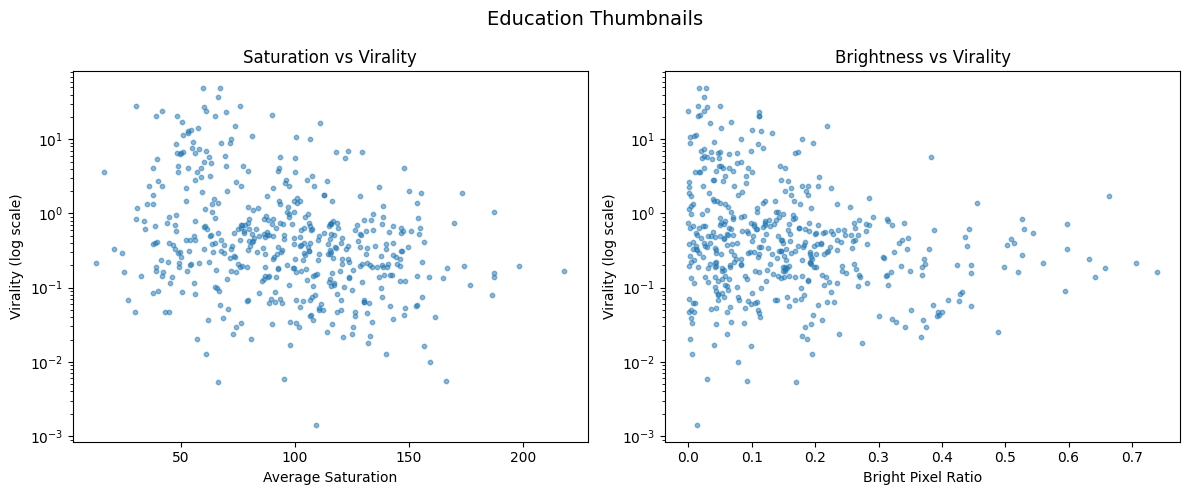

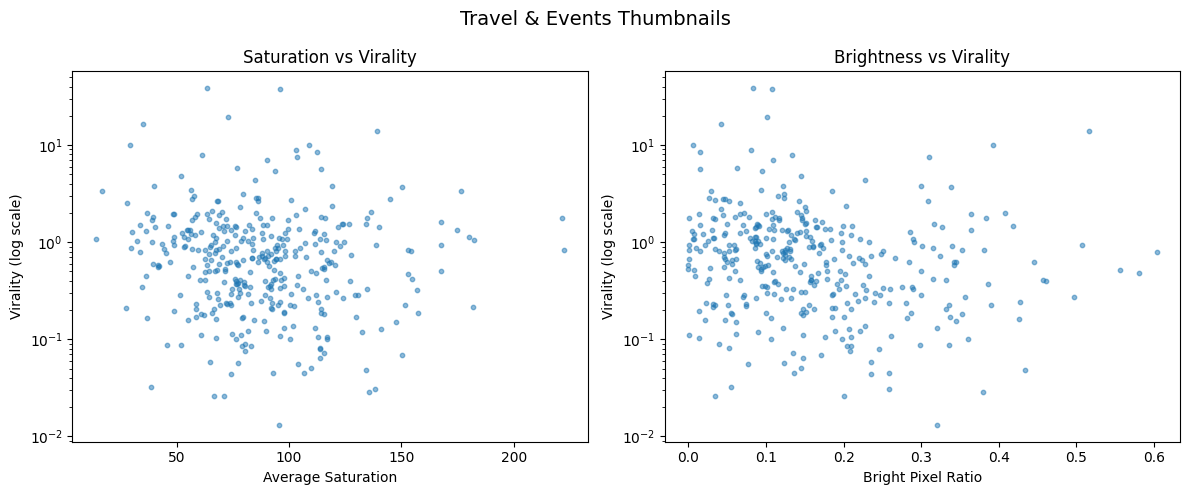

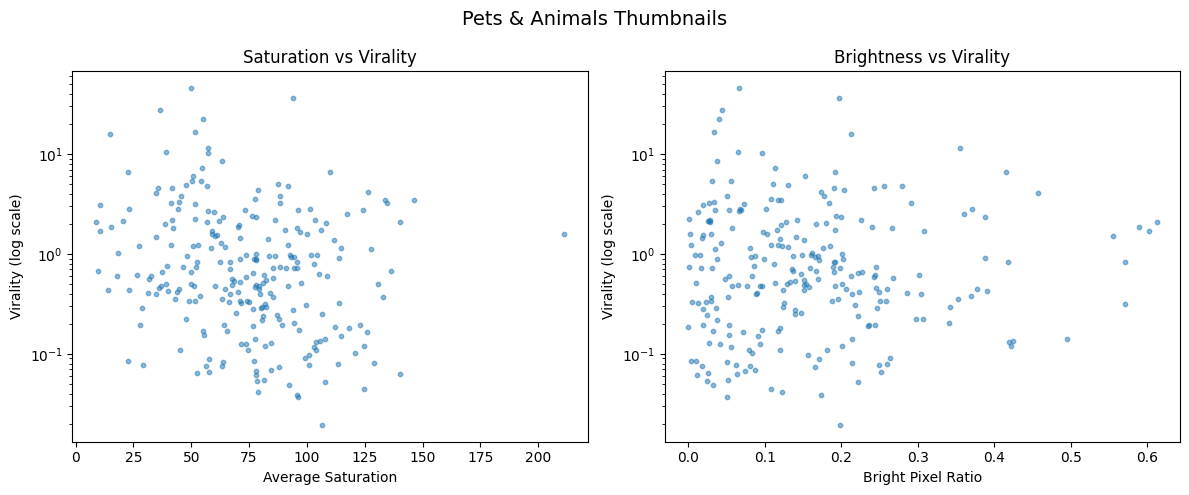

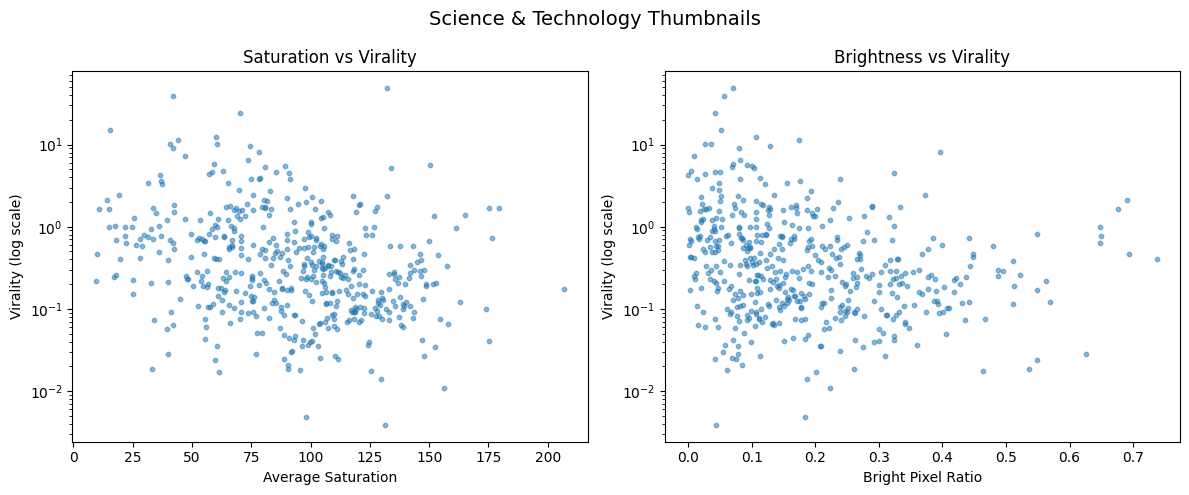

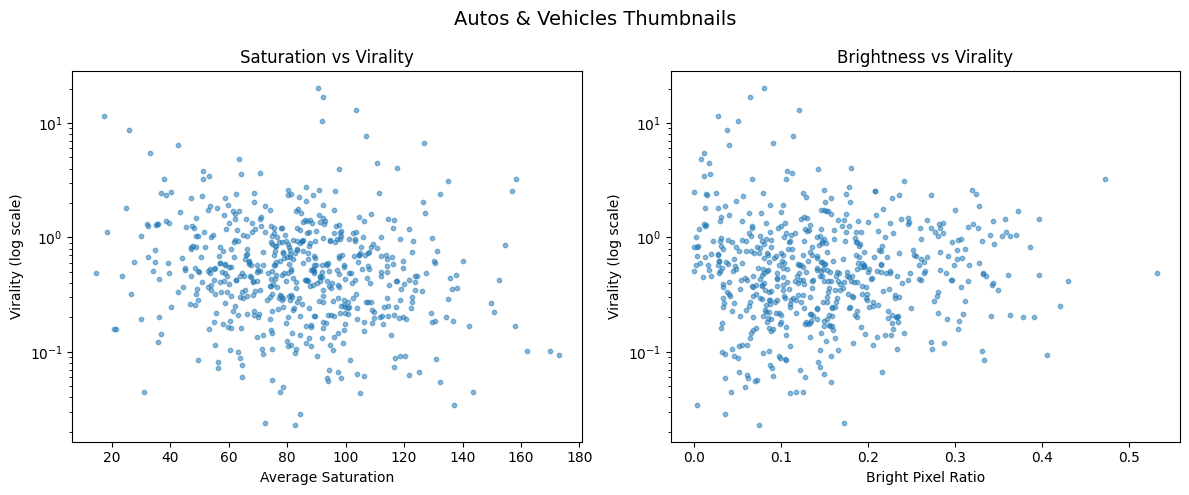

In [12]:
import matplotlib.pyplot as plt

categories = final_df["category"].unique()

for cat in categories:
    subset = final_df[final_df["category"] == cat]

    # skip very small datasets
    if len(subset) < 20:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------- Saturation --------
    axes[0].scatter(subset["avg_saturation"], subset["virality"], alpha=0.5, s=10)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Average Saturation")
    axes[0].set_ylabel("Virality (log scale)")
    axes[0].set_title("Saturation vs Virality")

    # -------- Brightness --------
    axes[1].scatter(subset["bright_ratio"], subset["virality"], alpha=0.5, s=10)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Bright Pixel Ratio")
    axes[1].set_ylabel("Virality (log scale)")
    axes[1].set_title("Brightness vs Virality")

    # -------- Main title --------
    fig.suptitle(f"{cat} Thumbnails", fontsize=14)

    plt.tight_layout()
    plt.show()

In [35]:
import scipy
corr_list = []

for cat in final_df["category"].unique():
    subset = final_df[final_df["category"] == cat]

    if len(subset) < 20:
        continue

    corr_list.append({
        "category": cat,

        "sat_pearson": subset["avg_saturation"].corr(subset["virality"], method="pearson"),
        "sat_spearman": subset["avg_saturation"].corr(subset["virality"], method="spearman"),

        "bright_pearson": subset["bright_ratio"].corr(subset["virality"], method="pearson"),
        "bright_spearman": subset["bright_ratio"].corr(subset["virality"], method="spearman"),
    })

corr_df = pd.DataFrame(corr_list)
print(corr_df)

                category  sat_pearson  sat_spearman  bright_pearson  \
0                  Music    -0.053302     -0.037019       -0.064987   
1                 Sports    -0.066920     -0.105222       -0.148748   
2                 Gaming     0.020803     -0.042910       -0.118099   
3         People & Blogs    -0.106474     -0.199312       -0.200672   
4          Entertainment    -0.061332     -0.134383       -0.129493   
5        News & Politics    -0.033924     -0.107235       -0.077473   
6                 Comedy    -0.120171     -0.210115       -0.187262   
7       Film & Animation    -0.057551     -0.025161       -0.141343   
8          Howto & Style     0.138443     -0.155648       -0.213162   
9              Education    -0.238613     -0.287859       -0.207629   
10       Travel & Events    -0.043706     -0.115207       -0.067236   
11        Pets & Animals    -0.133749     -0.222430       -0.052947   
12  Science & Technology    -0.120826     -0.295694       -0.150546   
13    

# Spearman Correlation

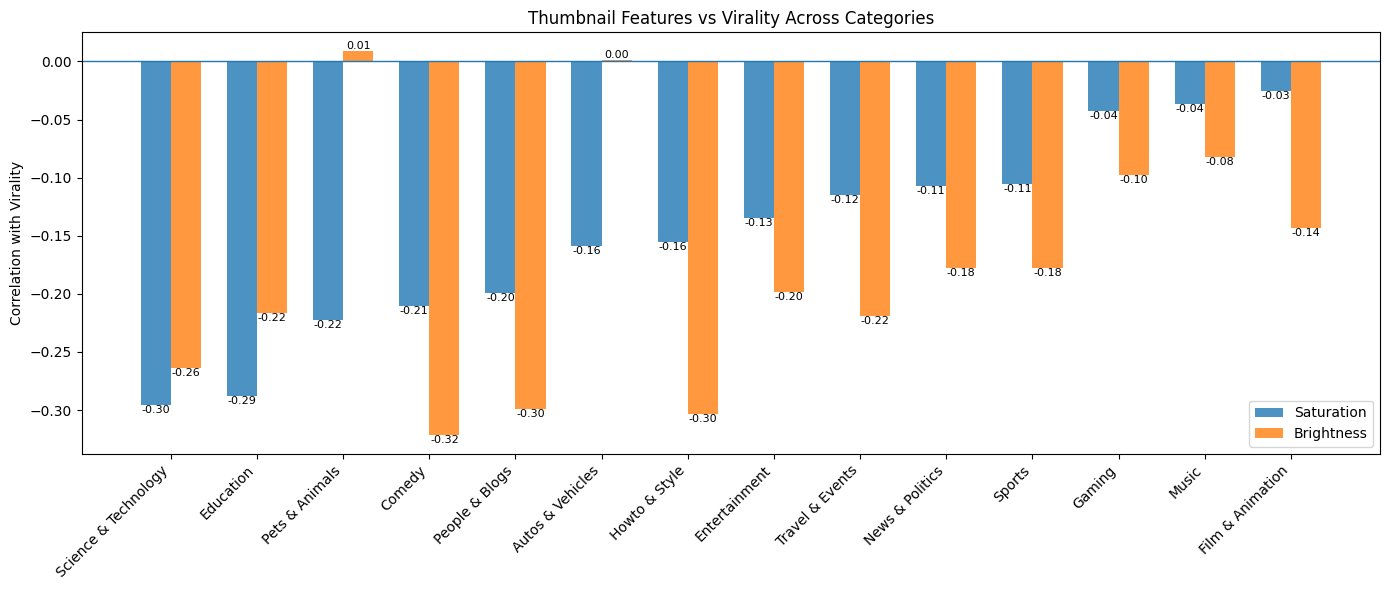

In [39]:
corr_df = corr_df.sort_values(by="sat_spearman")

categories = corr_df["category"]
x = np.arange(len(categories))

width = 0.35

plt.figure(figsize=(14, 6))

bars1 = plt.bar(
    x - width/2,
    corr_df["sat_spearman"],
    width,
    label="Saturation",
    alpha=0.8
)

bars2 = plt.bar(
    x + width/2,
    corr_df["bright_spearman"],
    width,
    label="Brightness",
    alpha=0.8
)

# -------- labels --------
plt.xticks(x, categories, rotation=45, ha="right")
plt.axhline(0, linewidth=1)

plt.ylabel("Correlation with Virality")
plt.title("Thumbnail Features vs Virality Across Categories")

plt.legend()

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom" if height > 0 else "top",
            fontsize=8
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()